In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# List attached dataset files (optional)
import os
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

def find_facilities_json() -> Path:
    matches = sorted(Path("/kaggle/input").rglob("facilities.json"))
    if not matches:
        raise FileNotFoundError("facilities.json not found under /kaggle/input")
    return matches[0]

data_path = find_facilities_json()
print(f"\nLoading: {data_path}")

with data_path.open() as f:
    bundle = json.load(f)

metadata = bundle["metadata"]
sites = bundle["facilities"]

print(f"Build date: {metadata['buildDate']}")
print(f"Facilities: {metadata['facilityCount']}")

/kaggle/input/datasets/endermaster67/us-data-center-facilities-dataset-4500-sites/facilities.json

Loading: /kaggle/input/datasets/endermaster67/us-data-center-facilities-dataset-4500-sites/facilities.json
Build date: 2026-06-26
Facilities: 4516


In [ ]:
rows = []
for site in sites:
    m = site["metrics"]
    rows.append({
        "id": site["id"],
        "name": site["name"],
        "operator": site.get("operator"),
        "lat": site["lat"],
        "lon": site["lon"],
        "state": site["state"],
        "county": site["county"],
        "county_fips": site["countyFips"],
        "market": site.get("market"),
        "footprint_sqft": site.get("footprintSqft"),
        "it_power_mw": m["itPowerMw"],
        "it_power_confidence": m["itPowerConfidence"],
        "water_mgy": m.get("waterConsumptionMgy"),
        "co2_tons_yr": m["annualCo2eTons"],
        "water_stress": m["waterStressScore"],
        "grid_co2_lb_mwh": m["gridCo2LbPerMwh"],
        "bci": m.get("bci"),
        "bci_reliable": m.get("bciReliable", False),
        "bci_label": m.get("bciLabel"),
    })

df = pd.DataFrame(rows)
df.head()

,id,name,operator,lat,lon,state,county,county_fips,market,footprint_sqft,it_power_mw,it_power_confidence,water_mgy,co2_tons_yr,water_stress,grid_co2_lb_mwh,bci,bci_reliable,bci_label
0,site:usa/texas/dallas/4025-midway,4025 Midway Rd (DFW11),Digital Realty,33.021626,-96.844818,Texas,Denton County,48121,Dallas,48500.0,4.4,official,11.56,18770,2.5,880,24.9,True,Low
1,site:usa/texas/dallas/2323-bryan-street,2323 Bryan Street (DFW10),Digital Realty,32.787212,-96.794219,Texas,Dallas County,48113,Dallas,40100.0,3.8,official,33.29,17938,4.5,880,37.7,True,Moderate
2,site:usa/texas/dallas/tel-x-dallas2,8435 Stemmons Freeway (DFW36),Digital Realty,32.827552,-96.873702,Texas,Dallas County,48113,Dallas,11000.0,1.0,official,8.76,4720,4.5,880,24.1,True,Low
3,site:usa/texas/dallas/1210-integrity-drive,1210 Integrity Drive (DFW18),Digital Realty,32.965314,-96.712785,Texas,Dallas County,48113,Dallas,227800.0,36.0,official,315.36,169938,4.5,880,79.7,True,Severe
4,site:usa/texas/dallas/1232-alma,1232 Alma Road (DFW16),Digital Realty,32.966034,-96.715646,Texas,Dallas County,48113,Dallas,49900.0,6.7,official,58.69,31627,4.5,880,45.5,True,Moderate


In [ ]:
print("Sites by state (top 10):")
print(df.groupby("state").size().sort_values(ascending=False).head(10))

print("\nEstimated IT load by state, MW (top 10):")
print(df.groupby("state")["it_power_mw"].sum().sort_values(ascending=False).head(10))

reliable = df[df["bci_reliable"] & df["bci"].notna()]
print(f"\nSites with reliable BCI: {len(reliable):,} / {len(df):,}")
print(reliable["bci_label"].value_counts())

Sites by state (top 10):
state
Virginia        611
Texas           489
California      316
Illinois        252
Ohio            220
Georgia         218
Arizona         160
New York        142
Pennsylvania    136
Florida         128
dtype: int64

Estimated IT load by state, MW (top 10):
state
Virginia        39184.24
Texas           24122.93
Illinois        18351.49
Ohio            10174.71
Arizona          8876.53
Georgia          8405.90
Oregon           7309.51
New Mexico       6047.43
California       5725.85
Pennsylvania     5533.77
Name: it_power_mw, dtype: float64

Sites with reliable BCI: 3,298 / 4,516
bci_label
Elevated    1770
Moderate     968
Severe       469
Low           91
Name: count, dtype: int64


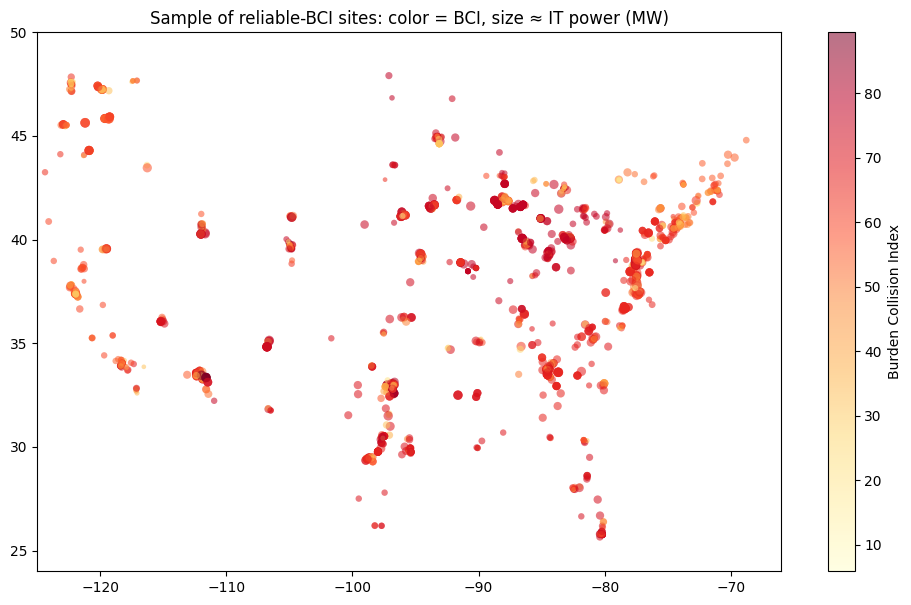

In [ ]:
plot_df = reliable.sample(n=min(2000, len(reliable)), random_state=42)
sizes = np.clip(plot_df["it_power_mw"], 0.5, 200)
sizes = 8 + 40 * (np.log1p(sizes) / np.log1p(sizes.max()))

fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(
    plot_df["lon"], plot_df["lat"],
    c=plot_df["bci"], s=sizes,
    cmap="YlOrRd", alpha=0.55, linewidths=0,
)
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_title("Sample of reliable-BCI sites: color = BCI, size ≈ IT power (MW)")
plt.colorbar(sc, ax=ax, label="Burden Collision Index")
plt.show()

In [ ]:
high_burden = reliable[
    (reliable["bci"] >= 50) & (reliable["water_stress"] >= 3)
].sort_values("bci", ascending=False)

print("High BCI (≥50) in water-stressed counties:")
print(
    high_burden[
        ["name", "operator", "state", "county", "it_power_mw", "bci", "water_stress"]
    ].head(15).to_string(index=False)
)

df.to_csv("/kaggle/working/facilities_flat.csv", index=False)
print("\nSaved /kaggle/working/facilities_flat.csv")

High BCI (≥50) in water-stressed counties:
                              name                   operator   state          county  it_power_mw  bci  water_stress
            Meta Mesa - Building 4                       Meta Arizona Maricopa County       125.31 89.4           4.7
            Meta Mesa - Building 1                       Meta Arizona Maricopa County       125.31 89.4           4.7
            Meta Mesa - Building 5                       Meta Arizona Maricopa County       125.31 89.4           4.7
            Meta Mesa - Building 3                       Meta Arizona Maricopa County       125.31 89.4           4.7
            Meta Mesa - Building 2                       Meta Arizona Maricopa County       125.31 89.4           4.7
             Google Mesa - Phase 3                     Google Arizona Maricopa County       150.00 89.4           4.7
            Apple Mesa Data Center                      Apple Arizona Maricopa County       267.65 89.4           4.7
             